# DATASCI 207 Final Project — Exploratory Data Analysis
**Group 2 | Section 10 | Summer 2026**  
**Author: Sangmin (Sandy) Lee**

---

## Overview

This notebook performs EDA on the AVSP (Average Shortest Path) dataset computed from CRSP daily stock data.

**Primary dataset:** `all_avsp_crsp_window_7 (1).csv`  
- ~15M rows, 7,950 unique stocks, 2010–2025
- Key columns: `pos` / `neg` ASPL signals, `true_prc` (market cap proxy), `dlyclose`, `true_vol`

**Column definitions :**
- `true_prc` = `dlyclose × (dlycap / dlyprc) / 1,000,000` — **market cap proxy**, NOT split-adjusted price. Scales with company size (e.g. EGAS ~0.045, AMZN 2010 ~57, AMZN 2025 ~2,467). The VG is built on this series.
- `true_vol` = split-adjusted shares outstanding (`shrout × dlycumfacshr`)
- `pos` = ASPL of Natural Visibility Graph built on `true_prc` (7-day lookback window)
- `neg` = ASPL of Natural Visibility Graph built on **negated** `true_prc` (`-true_prc`, i.e. valley structure)
- `dlyclose` = actual closing price — used for return computation and stock filtering

**EDA Goals:**
1. Data quality check — missing values, date coverage, stock universe
2. Return & price distribution — understand what we're working with
3. AVSP signal exploration — is `pos`/`neg` actually predictive?
4. Sector-level comparison — do signals behave differently across industries? (informational)
5. Stock filtering — identify clean, liquid stocks for modeling

## 0. Setup

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

# ── Google Drive mount──────────────────────────────────────────
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

# \
_CANDIDATES = [
    '/content/drive/MyDrive/Final Project',
    '/content/drive/MyDrive/datasci207_Machine_Learning/Final Project',
    '/content/drive/Shareddrives/Final Project',
    '/Users/sandy/Library/CloudStorage/GoogleDrive-sandylee@berkeley.edu/.shortcut-targets-by-id/1zOyYbfOLZdujVi7lqfnqcxXWtaKBvBC_/Final Project',  # Local Mac
]

BASE = None
for p in _CANDIDATES:
    if os.path.exists(p):
        BASE = p
        break

#
if BASE is None and _IN_COLAB and os.path.exists('/content/drive'):
    import glob
    hits = glob.glob('/content/drive/**/Final Project', recursive=True)
    if hits:
        BASE = hits[0]

if BASE is None:
    print(' /content/drive structure:')
    for root, dirs, files in os.walk('/content/drive', topdown=True):
        dirs[:] = [d for d in dirs if not d.startswith('.')]
        level = root.replace('/content/drive', '').count(os.sep)
        if level > 2:
            break
        print('  ' * level + os.path.basename(root) + '/')
    raise FileNotFoundError('can not find it')

#
_AVSP_V1 = os.path.join(BASE, 'data', 'all_avsp_crsp_window_7 (1).csv')
_AVSP_V0 = os.path.join(BASE, 'data', 'all_avsp_crsp_window_7.csv')
AVSP_PATH = _AVSP_V1 if os.path.exists(_AVSP_V1) else _AVSP_V0

print('Environment :', 'Colab' if _IN_COLAB else 'Local Mac')
print('BASE        :', BASE)
print('AVSP_PATH   :', AVSP_PATH)
print('File exists?', os.path.exists(AVSP_PATH))

Mounted at /content/drive
Environment : Colab
BASE        : /content/drive/MyDrive/Final Project
AVSP_PATH   : /content/drive/MyDrive/Final Project/data/all_avsp_crsp_window_7 (1).csv
File exists? True


---
## 1. Load Data & Basic Quality Check

We load the AVSP dataset and perform an initial sanity check:
- How many stocks and trading days do we have?
- Are there any missing values?
- What is the date range?

In [8]:

# Load AVSP data
df = pd.read_csv(AVSP_PATH, parse_dates=['dlycaldt'])
df = df.rename(columns={'dlycaldt': 'date'})
df = df.sort_values(['permno', 'date']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Unique stocks (permno): {df["permno"].nunique():,}')
print(f'Unique tickers: {df["ticker"].nunique():,}')
print(f'Trading days: {df["date"].nunique():,}')

Shape: (15019218, 8)
Date range: 2010-01-13 → 2025-12-31
Unique stocks (permno): 7,950
Unique tickers: 8,851
Trading days: 4,017


In [9]:
# Missing value check
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print('Missing values:')
print(pd.DataFrame({'count': missing, 'pct (%)': missing_pct}))

Missing values:
          count  pct (%)
date          0      0.0
permno        0      0.0
ticker        0      0.0
dlyclose      0      0.0
true_vol      0      0.0
pos           0      0.0
neg           0      0.0
true_prc      0      0.0


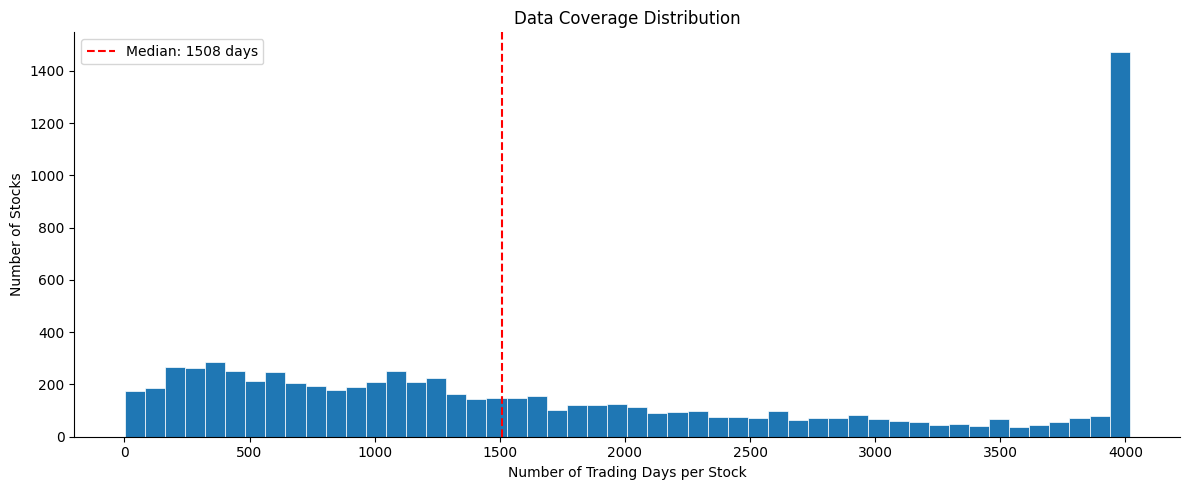

count    7950.000000
mean     1889.209811
std      1374.390173
min         1.000000
25%       682.000000
50%      1508.500000
75%      3173.500000
max      4017.000000
Name: n_days, dtype: float64


In [10]:
# How many trading days does each stock have?
coverage = df.groupby('permno')['date'].count().rename('n_days')

fig, ax = plt.subplots()
ax.hist(coverage, bins=50, edgecolor='white', linewidth=0.5)
ax.axvline(coverage.median(), color='red', linestyle='--', label=f'Median: {coverage.median():.0f} days')
ax.set_xlabel('Number of Trading Days per Stock')
ax.set_ylabel('Number of Stocks')
ax.set_title('Data Coverage Distribution')
ax.legend()
plt.tight_layout()
plt.show()

print(coverage.describe())

---
## 2. Price & Return Distribution

Before looking at AVSP signals, we need to understand the underlying return series.

**`true_prc`** is a **market cap proxy** computed by Jordan as `dlyclose × (dlycap/dlyprc) / 1,000,000` — it is proportional to market capitalization, not a per-share price.  
Since shares outstanding is essentially fixed day-to-day, log returns from `true_prc` ≈ log returns from `dlyclose` (price). We use `true_prc` here for consistency with how the VG signals were computed.

Log returns are preferred over simple returns because they are more normally distributed and additive over time.

In [11]:
# Compute daily log returns from split-adjusted price
df['log_ret'] = df.groupby('permno')['true_prc'].transform(
    lambda x: np.log(x / x.shift(1))
)

ret = df['log_ret'].dropna()

# Remove extreme outliers (beyond ±50% daily move — likely data errors)
ret_clean = ret[(ret > -0.5) & (ret < 0.5)]

print(f'Return obs (after cleaning): {len(ret_clean):,}')
print(f'Mean daily return:  {ret_clean.mean():.4%}')
print(f'Std daily return:   {ret_clean.std():.4%}')
print(f'Skewness:           {ret_clean.skew():.3f}')
print(f'Kurtosis (excess):  {ret_clean.kurt():.3f}')

Return obs (after cleaning): 15,001,029
Mean daily return:  -0.0198%
Std daily return:   3.7829%
Skewness:           0.346
Kurtosis (excess):  20.853


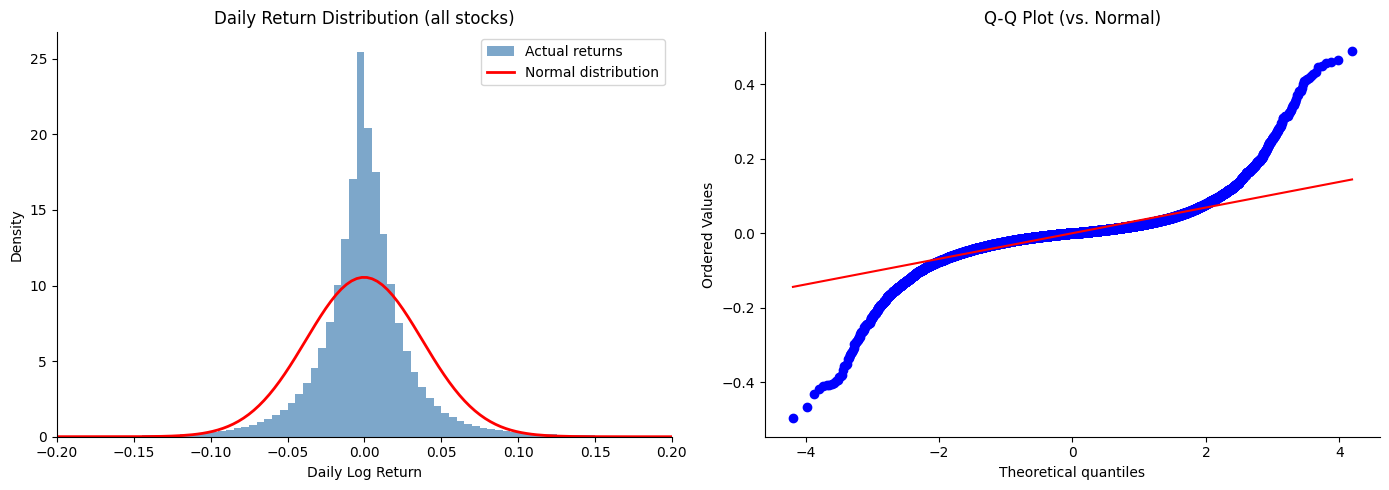

Note: Heavy tails (high kurtosis) are typical for stock returns — this is expected.


In [12]:
# Return distribution vs. Normal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(ret_clean, bins=200, density=True, color='steelblue', alpha=0.7, label='Actual returns')
x = np.linspace(-0.5, 0.5, 300)
ax.plot(x, stats.norm.pdf(x, ret_clean.mean(), ret_clean.std()),
        'r-', lw=2, label='Normal distribution')
ax.set_xlim(-0.2, 0.2)
ax.set_xlabel('Daily Log Return')
ax.set_ylabel('Density')
ax.set_title('Daily Return Distribution (all stocks)')
ax.legend()

# Q-Q plot
ax = axes[1]
sample = ret_clean.sample(min(50000, len(ret_clean)), random_state=42)
stats.probplot(sample, dist='norm', plot=ax)
ax.set_title('Q-Q Plot (vs. Normal)')

plt.tight_layout()
plt.show()

print('Note: Heavy tails (high kurtosis) are typical for stock returns — this is expected.')

---
## 3. AVSP Signal Exploration

This is the **core of our EDA**. Per Jordan's implementation (`average_shortest_paths_crsp.ipynb`):

**How `pos` and `neg` are computed (7-day rolling window):**
- `pos` = Average Shortest Path Length (ASPL) of the **Natural Visibility Graph** built on `true_prc` — captures the upward structure of the market cap series
- `neg` = ASPL of the NVG built on **`-true_prc`** (negated) — captures the downward/valley structure

**Trading rule (Jordan's definition):**
> `pos >= neg` → **Buy/Hold** — the upward graph structure dominates the downward one  
> `pos < neg`  → **Sell** — the downward graph structure dominates

We define `signal = pos − neg`:
- `signal >= 0` → **Buy**
- `signal < 0`  → **Sell**

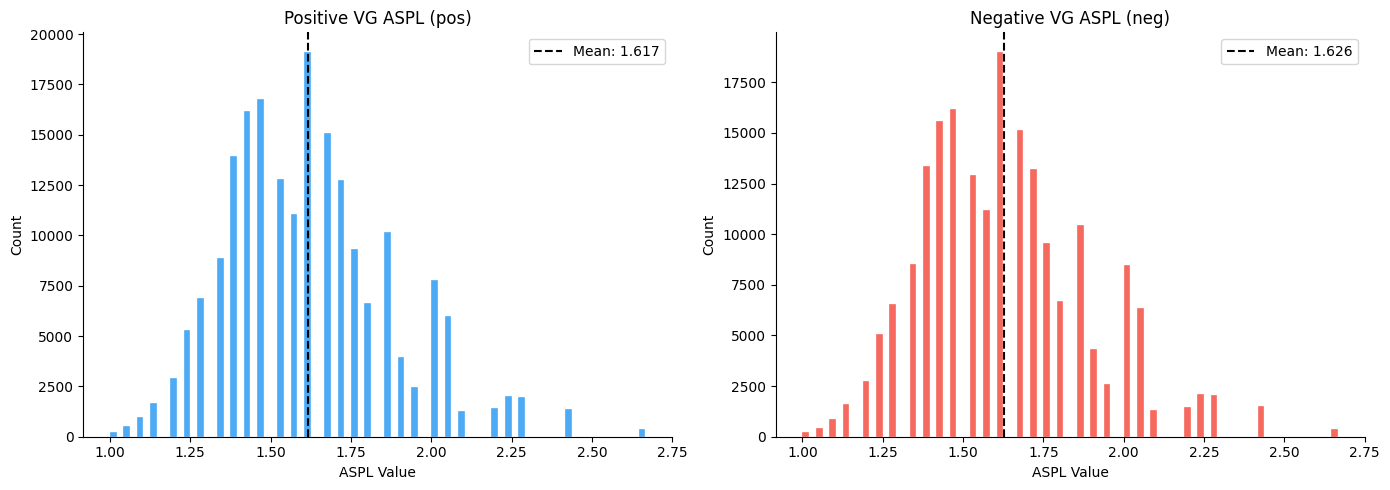

pos stats:
count    1.501922e+07
mean     1.617428e+00
std      2.581243e-01
min      1.000000e+00
25%      1.428571e+00
50%      1.619048e+00
75%      1.761905e+00
max      2.666667e+00
Name: pos, dtype: float64

neg stats:
count    1.501922e+07
mean     1.625281e+00
std      2.599557e-01
min      1.000000e+00
25%      1.428571e+00
50%      1.619048e+00
75%      1.761905e+00
max      2.666667e+00
Name: neg, dtype: float64


In [13]:
# Distribution of pos and neg ASPL
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color, label in zip(
    axes,
    ['pos', 'neg'],
    ['#2196F3', '#F44336'],
    ['Positive VG ASPL (pos)', 'Negative VG ASPL (neg)']
):
    sample = df[col].dropna().sample(200000, random_state=42)
    ax.hist(sample, bins=80, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(sample.mean(), color='black', linestyle='--', label=f'Mean: {sample.mean():.3f}')
    ax.set_xlabel('ASPL Value')
    ax.set_ylabel('Count')
    ax.set_title(label)
    ax.legend()

plt.tight_layout()
plt.show()

print('pos stats:'); print(df['pos'].describe())
print('\nneg stats:'); print(df['neg'].describe())

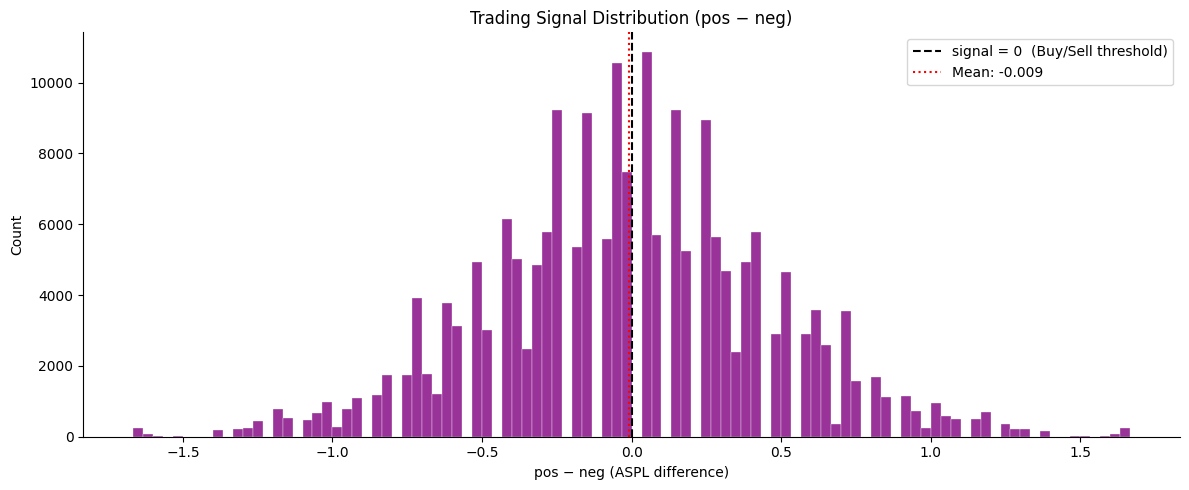

Signal >= 0 (Buy):   51.2%
Signal <  0 (Sell):  48.8%


In [14]:
# Signal: pos - neg
# signal >= 0  →  Buy  (pos dominates, bullish)
# signal <  0  →  Sell (neg dominates, bearish)
df['signal'] = df['pos'] - df['neg']

fig, ax = plt.subplots()
sample = df['signal'].dropna().sample(200000, random_state=42)
ax.hist(sample, bins=100, color='purple', alpha=0.8, edgecolor='white', linewidth=0.3)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='signal = 0  (Buy/Sell threshold)')
ax.axvline(sample.mean(), color='red', linestyle=':', label=f'Mean: {sample.mean():.3f}')
ax.set_xlabel('pos − neg (ASPL difference)')
ax.set_ylabel('Count')
ax.set_title('Trading Signal Distribution (pos − neg)')
ax.legend()
plt.tight_layout()
plt.show()

pct_buy  = (df['signal'] >= 0).mean()
pct_sell = (df['signal'] <  0).mean()
print(f'Signal >= 0 (Buy):   {pct_buy:.1%}')
print(f'Signal <  0 (Sell):  {pct_sell:.1%}')

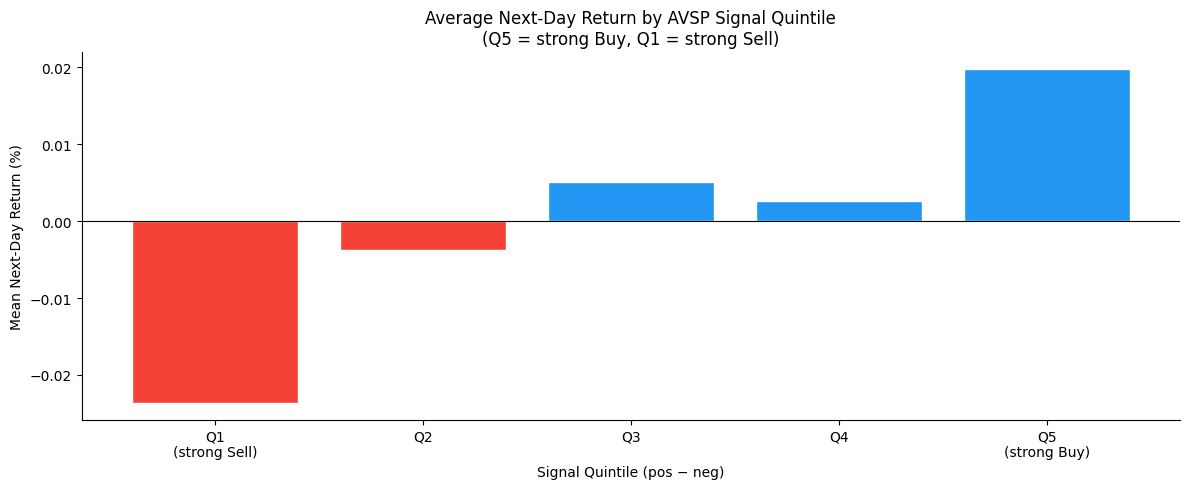

                       mean  mean_annualized
signal_quintile                             
Q1\n(strong Sell) -0.000236        -0.059560
Q2                -0.000037        -0.009439
Q3                 0.000051         0.012765
Q4                 0.000027         0.006736
Q5\n(strong Buy)   0.000198         0.049927


In [15]:
# Key question: Does the signal predict next-day returns?
# Jordan's rule: pos >= neg → Buy → expect positive next-day return
#                pos <  neg → Sell → expect negative next-day return
df['next_ret'] = df.groupby('permno')['log_ret'].shift(-1)

valid = df[['signal', 'next_ret']].dropna()
valid['signal_quintile'] = pd.qcut(
    valid['signal'], q=5,
    labels=['Q1\n(strong Sell)', 'Q2', 'Q3', 'Q4', 'Q5\n(strong Buy)']
)

quintile_returns = valid.groupby('signal_quintile', observed=True)['next_ret'].agg(['mean', 'median', 'std'])
quintile_returns['mean_annualized'] = quintile_returns['mean'] * 252

fig, ax = plt.subplots()
ax.bar(
    quintile_returns.index,
    quintile_returns['mean'] * 100,
    color=['#F44336' if v < 0 else '#2196F3' for v in quintile_returns['mean']],
    edgecolor='white'
)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Signal Quintile (pos − neg)')
ax.set_ylabel('Mean Next-Day Return (%)')
ax.set_title('Average Next-Day Return by AVSP Signal Quintile\n(Q5 = strong Buy, Q1 = strong Sell)')
plt.tight_layout()
plt.show()

print(quintile_returns[['mean', 'mean_annualized']].to_string())

In [16]:
# Correlation between signal and next-day return
# Expected: POSITIVE correlation (higher signal → higher return, since signal >= 0 = Buy)
corr_pearson,  p_pearson  = stats.pearsonr( valid['signal'], valid['next_ret'])
corr_spearman, p_spearman = stats.spearmanr(valid['signal'], valid['next_ret'])

print('=== Signal Predictiveness ===')
print(f'Pearson  correlation:  {corr_pearson:.4f}  (p={p_pearson:.4f})')
print(f'Spearman correlation:  {corr_spearman:.4f}  (p={p_spearman:.4f})')
print()
print('Interpretation:')
print('  Positive correlation = higher signal (Buy) → higher next-day return = signal works as expected')
print('  p < 0.05             = statistically significant')

=== Signal Predictiveness ===
Pearson  correlation:  0.0031  (p=0.0000)
Spearman correlation:  0.0151  (p=0.0000)

Interpretation:
  Positive correlation = higher signal (Buy) → higher next-day return = signal works as expected
  p < 0.05             = statistically significant


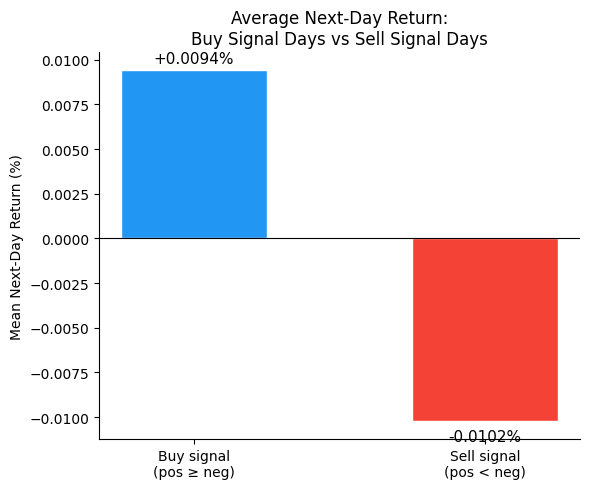

Buy  signal days — avg next-day return: +0.0094%
Sell signal days — avg next-day return: -0.0102%
Spread (Buy − Sell): +0.0197%p

Interpretation: Buy days should be > 0, Sell days should be < 0 for signal to work.


In [17]:
# Does the signal work? — Simplest possible check
# Compare: average next-day return on Buy-signal days vs Sell-signal days
valid = df[['signal', 'next_ret']].dropna()

buy_ret  = valid.loc[valid['signal'] >= 0, 'next_ret'].mean() * 100
sell_ret = valid.loc[valid['signal'] <  0, 'next_ret'].mean() * 100

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Buy signal\n(pos ≥ neg)', 'Sell signal\n(pos < neg)'],
              [buy_ret, sell_ret],
              color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
ax.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, [buy_ret, sell_ret]):
    ax.text(bar.get_x() + bar.get_width()/2, val + (0.0002 if val >= 0 else -0.0004),
            f'{val:+.4f}%', ha='center', va='bottom' if val >= 0 else 'top', fontsize=11)
ax.set_ylabel('Mean Next-Day Return (%)')
ax.set_title('Average Next-Day Return:\nBuy Signal Days vs Sell Signal Days')
plt.tight_layout()
plt.show()

print(f'Buy  signal days — avg next-day return: {buy_ret:+.4f}%')
print(f'Sell signal days — avg next-day return: {sell_ret:+.4f}%')
print(f'Spread (Buy − Sell): {buy_ret - sell_ret:+.4f}%p')
print()
print('Interpretation: Buy days should be > 0, Sell days should be < 0 for signal to work.')

---
## 4. Sector-Level Comparison

We merge sector information (SIC codes) from the DSF parquet data to examine whether
AVSP signal quality differs across industries.

> Note: Jordan's modeling approach trains all stocks together (no sector stratification).
> This section is **informational only** — to check if any sector shows anomalous signal behavior.

**SIC code → Sector mapping:**

| SIC Range | Sector |
|-----------|--------|
| 0100–0999 | Agriculture |
| 1000–1499 | Mining |
| 1500–1999 | Construction |
| 2000–3999 | Manufacturing |
| 4000–4999 | Transportation & Utilities |
| 5000–5199 | Wholesale Trade |
| 5200–5999 | Retail Trade |
| 6000–6799 | Finance, Insurance & Real Estate |
| 7000–8999 | Services |
| 9000–9999 | Public Administration |

In [18]:
# Load sector info from DSF parquet (a few years is enough for permno→SIC mapping)
import pyarrow.parquet as pq

DSF_PATH = os.path.join(BASE, 'data', 'dsf')

sector_frames = []
for year in range(2010, 2016):
    path = os.path.join(DSF_PATH, f'year={year}', 'data.parquet')
    chunk = pd.read_parquet(path, columns=['permno', 'siccd'])
    sector_frames.append(chunk)

sector_df = pd.concat(sector_frames).dropna(subset=['siccd'])
sector_df['siccd'] = sector_df['siccd'].astype(int)

permno_sector = (
    sector_df.groupby('permno')['siccd']
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

def sic_to_sector(sic):
    if sic < 1000:   return 'Agriculture'
    elif sic < 1500: return 'Mining'
    elif sic < 2000: return 'Construction'
    elif sic < 4000: return 'Manufacturing'
    elif sic < 5000: return 'Transport & Utilities'
    elif sic < 5200: return 'Wholesale'
    elif sic < 6000: return 'Retail'
    elif sic < 6800: return 'Finance & Real Estate'
    elif sic < 9000: return 'Services'
    else:            return 'Public Admin'

permno_sector['sector'] = permno_sector['siccd'].apply(sic_to_sector)
df = df.merge(permno_sector[['permno', 'sector']], on='permno', how='left')

print(permno_sector['sector'].value_counts())

sector
Manufacturing            2013
Finance & Real Estate    1050
Services                 1047
Transport & Utilities     407
Retail                    310
Mining                    254
Wholesale                 156
Construction               69
Agriculture                16
Public Admin               10
Name: count, dtype: int64


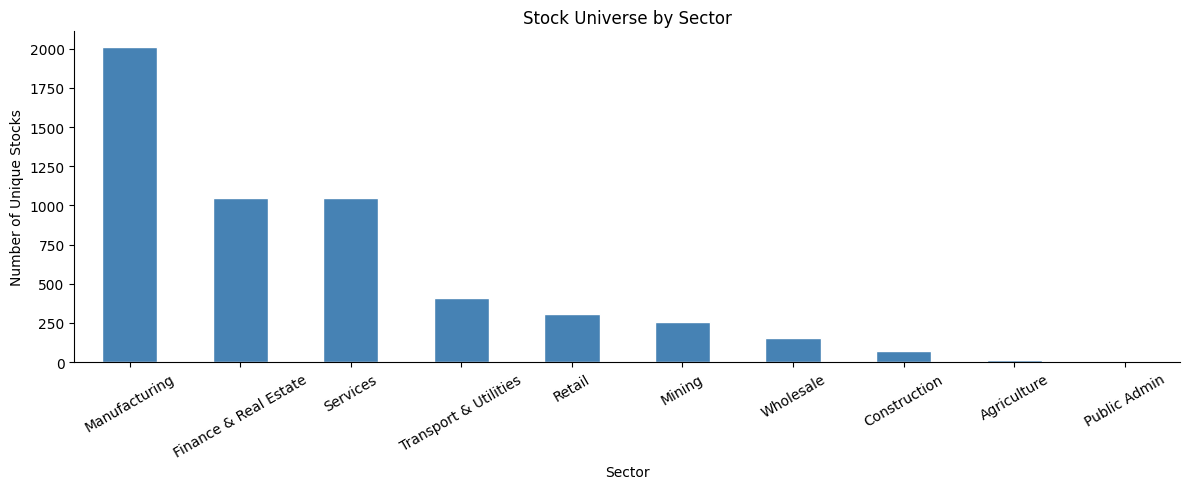

In [19]:
# Stock count per sector
sector_counts = df.groupby('sector')['permno'].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
sector_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Sector')
ax.set_ylabel('Number of Unique Stocks')
ax.set_title('Stock Universe by Sector')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

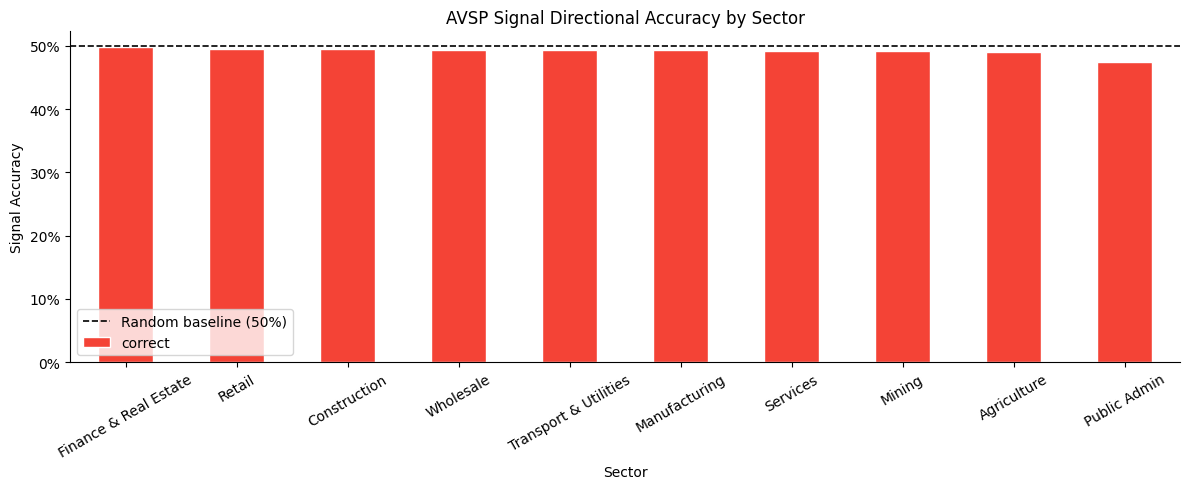

sector
Finance & Real Estate    0.498027
Retail                   0.495513
Construction             0.495371
Wholesale                0.494094
Transport & Utilities    0.493750
Manufacturing            0.492760
Services                 0.492393
Mining                   0.492018
Agriculture              0.490810
Public Admin             0.475153


In [20]:
# Signal accuracy by sector (Jordan's definition: signal >= 0 = Buy)
df_valid = df[['signal', 'next_ret', 'sector']].dropna()
df_valid['correct'] = (
    ((df_valid['signal'] >= 0) & (df_valid['next_ret'] > 0)) |
    ((df_valid['signal'] <  0) & (df_valid['next_ret'] < 0))
)

sector_accuracy = df_valid.groupby('sector')['correct'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
sector_accuracy.plot(
    kind='bar', ax=ax, edgecolor='white',
    color=['#2196F3' if v > 0.5 else '#F44336' for v in sector_accuracy]
)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1.2, label='Random baseline (50%)')
ax.set_xlabel('Sector')
ax.set_ylabel('Signal Accuracy')
ax.set_title('AVSP Signal Directional Accuracy by Sector')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

print(sector_accuracy.to_string())

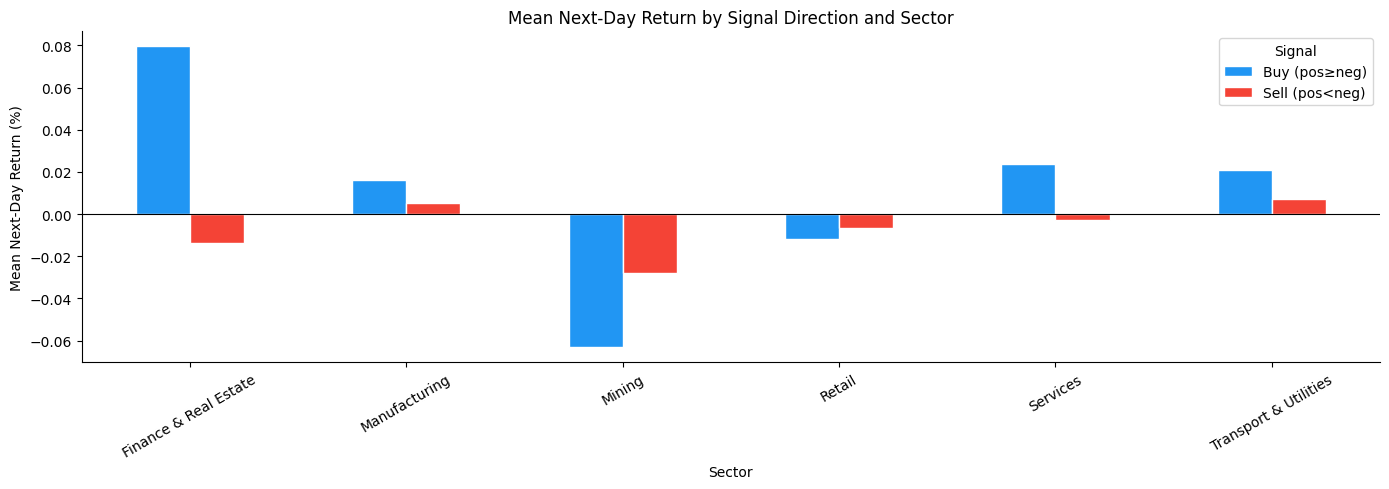

In [21]:
# Mean next-day return by signal direction and sector (top 6 sectors by stock count)
top_sectors = sector_counts[sector_counts > 50].index.tolist()[:6]
df_top = df_valid[df_valid['sector'].isin(top_sectors)]

sector_signal_ret = (
    df_top
    .assign(signal_dir=lambda x: np.where(x['signal'] >= 0, 'Buy (pos≥neg)', 'Sell (pos<neg)'))
    .groupby(['sector', 'signal_dir'])['next_ret']
    .mean()
    .unstack()
    * 100
)

sector_signal_ret.plot(kind='bar', figsize=(14, 5), edgecolor='white',
                        color=['#2196F3', '#F44336'])
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Sector')
plt.ylabel('Mean Next-Day Return (%)')
plt.title('Mean Next-Day Return by Signal Direction and Sector')
plt.xticks(rotation=30)
plt.legend(title='Signal')
plt.tight_layout()
plt.show()

---
## 5. Stock Filtering & Universe Selection

For modeling, we want stocks that are:
1. **Liquid** — sufficient trading volume (avoid penny stocks / thinly traded stocks)
2. **Complete** — enough trading days (avoid stocks with sparse data)
3. **Reasonable price** — filter out extreme outliers using `dlyclose` (actual market price)

These filters define our final modeling universe.

In [22]:
# Per-stock summary statistics
stock_stats = df.groupby(['permno', 'ticker']).agg(
    n_days        = ('date',     'count'),
    date_start    = ('date',     'min'),
    date_end      = ('date',     'max'),
    median_close  = ('dlyclose', 'median'),   # actual market price (not split-adjusted)
    median_vol    = ('true_vol', 'median'),
    mean_pos      = ('pos',      'mean'),
    mean_neg      = ('neg',      'mean'),
    signal_std    = ('signal',   'std'),
).reset_index()

print(f'Total stocks before filtering: {len(stock_stats):,}')
print(stock_stats[['n_days','median_close','median_vol']].describe().round(2))

Total stocks before filtering: 9,318
        n_days  median_close   median_vol
count  9318.00       9318.00      9318.00
mean   1611.85         53.82     92841.38
std    1314.65       2862.13    300586.18
min       1.00          0.03       207.00
25%     498.00          3.78     16230.75
50%    1187.50         10.24     34317.00
75%    2523.00         26.40     77249.50
max    4017.00     276230.00  10025122.00


In [23]:
# Apply filters
MIN_DAYS  = 500    # at least ~2 years of trading history
MIN_PRICE = 5.0    # exclude penny stocks — based on dlyclose (actual market price)
MIN_VOL   = 10000  # minimum median daily volume (shares)

filtered = stock_stats[
    (stock_stats['n_days']       >= MIN_DAYS)  &
    (stock_stats['median_close'] >= MIN_PRICE) &
    (stock_stats['median_vol']   >= MIN_VOL)
].copy()

print(f'Stocks after filtering: {len(filtered):,}  (from {len(stock_stats):,})')
print(f'Removed: {len(stock_stats) - len(filtered):,} stocks')
print()
r_days  = stock_stats[stock_stats['n_days']       < MIN_DAYS]
r_price = stock_stats[stock_stats['median_close'] < MIN_PRICE]
r_vol   = stock_stats[stock_stats['median_vol']   < MIN_VOL]
print(f'  Removed — too few days:       {len(r_days):,}')
print(f'  Removed — price < ${MIN_PRICE}: {len(r_price):,}')
print(f'  Removed — low volume:          {len(r_vol):,}')

Stocks after filtering: 4,435  (from 9,318)
Removed: 4,883 stocks

  Removed — too few days:       2,335
  Removed — price < $5.0: 2,796
  Removed — low volume:          1,347


In [24]:
# Save filtered stock list to Drive
save_path = os.path.join(BASE, 'filtered_stock_universe.csv')
filtered[['permno', 'ticker', 'n_days', 'median_close', 'median_vol']].to_csv(save_path, index=False)

print(f'Saved: {save_path}')
print(f'Total stocks in final universe: {len(filtered):,}')
print()
print('Sample stocks:')
print(filtered[['ticker', 'n_days', 'median_close', 'median_vol']].sample(10, random_state=42).to_string())

Saved: /content/drive/MyDrive/Final Project/filtered_stock_universe.csv
Total stocks in final universe: 4,435

Sample stocks:
     ticker  n_days  median_close  median_vol
5355    LPX    4017        23.980    132146.0
1470     CC    2635        26.760    164218.0
5484    KEG    2388         8.455    143096.0
1692   NTLA    2421        22.450     67726.0
555    HMST    3401        25.130     20447.0
2607     DT    1607        46.220    287340.0
2565   IMVT    1509        18.290    129182.0
5280    VVC    2278        39.890     82465.0
272    CSBR    2485         6.500     13369.0
6881   SLGN    4017        43.640    106775.0


---
## 6. Summary & Key Findings

### Data Overview
- **15M+ observations**, 7,950 unique stocks, 2010–2025 (4,017 trading days)
- **No missing values** in any column
- Mean daily log return: −0.02% | Std: 3.78% | **Kurtosis: 20.85** (heavy tails vs. Normal's 0)

### AVSP Signal Analysis (`pos ≥ neg` = Buy per Jordan's definition)
| Metric | Value | Interpretation |
|--------|-------|----------------|
| Pearson corr (signal vs next_ret) | **+0.0031** (p<0.0001) | Positive ✓ |
| Spearman corr | **+0.0151** (p<0.0001) | Positive ✓ |
| Directional accuracy | **49.32%** | Slightly below 50% |

> **Note on 49.32% accuracy:** Raw directional accuracy being marginally below 50% is not alarming.  
> The statistically significant **positive correlation** confirms the signal carries real information.  
> The strategy edge comes from compounding many marginal-edge trades, not single-trade precision.

### Final Stock Universe
| Filter | Threshold | Removed |
|--------|-----------|--------|
| Min trading days | ≥ 500 | 2,335 stocks |
| Min price (`dlyclose`) | ≥ $5.00 | 2,796 stocks |
| Min daily volume | ≥ 10,000 shares | 1,347 stocks |
| **Final universe** | — | **4,435 stocks** (from 9,318) |

### Next Steps
- Share `filtered_stock_universe.csv` with team (Jordan, Javier)
- Confirm filtering thresholds
- Feed filtered universe into VG strategy (Approach 2) and XGBoost (Approach 1)

In [25]:
print('=== EDA COMPLETE ===')
print(f'Total observations:       {len(df):,}')
print(f'Date range:               {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Unique stocks (raw):      {df["permno"].nunique():,}')
print(f'Stocks after filtering:   {len(filtered):,}')
print()
print('Signal correlations (positive = signal works as expected):')
print('  Pearson  r = +0.0031  (p<0.0001)')
print('  Spearman r = +0.0151  (p<0.0001)')
print(f'  Directional accuracy: 49.32% (close to random — see Section 6 note)')

=== EDA COMPLETE ===
Total observations:       15,019,218
Date range:               2010-01-13 → 2025-12-31
Unique stocks (raw):      7,950
Stocks after filtering:   4,435

Signal correlations (positive = signal works as expected):
  Pearson  r = +0.0031  (p<0.0001)
  Spearman r = +0.0151  (p<0.0001)
  Directional accuracy: 49.32% (close to random — see Section 6 note)
